## Python-Based Unemployment Analysis

- Examine unemployment rate data (percentage of unemployed individuals).

- Apply Python for cleaning, exploring, and visualizing unemployment patterns.

- Assess how Covid-19 affected unemployment rates.

- Detect major seasonal trends or recurring patterns.

- Deliver actionable insights to guide economic or social policy decisions.

                                                             Data Science Internship @ CodeAlpha                                                     .                 

                                                         Intern Name: Mohamed Elyass Mohamed Ahmed                                                                    .

                                                             Date Done The Project: 26/05/2026                                                                        .

In [104]:
import pandas as pd    
import numpy as np    
import matplotlib.pyplot as plt   
import seaborn as sns 

In [105]:
df = pd.read_csv(r'C:\Users\Elfadil\Downloads\archive\Unemployment_Rate_upto_11_2020.csv')

In [106]:
df.head(5)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


### A- Data Checking & cleaning
##### We have to check:
##### << Missing values, Duplicates, Data types, Outliers, Inconsistent categories, Useless columns, String whitespace >>

In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    str    
 1    Date                                     267 non-null    str    
 2    Frequency                                267 non-null    str    
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    str    
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 18.9 KB


In [108]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


1- Checking String whitespace in columns

In [111]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')

In [112]:
df = df.rename(columns={
    'Region': 'Region',
    ' Date': 'Date',
    ' Frequency': 'Frequency',
    ' Estimated Unemployment Rate (%)': 'Estimated_Unemployment_Rate',
    ' Estimated Employed': 'Estimated_Employed',
    ' Estimated Labour Participation Rate (%)': 'Estimated_Labour_Participation_Rate',
    'Region_Code': 'Region_Code',
    'longitude': 'longitude',
    'latitude': 'latitude'
})

In [116]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated_Unemployment_Rate',
       'Estimated_Employed', 'Estimated_Labour_Participation_Rate', 'Region.1',
       'longitude', 'latitude'],
      dtype='str')

##### All outliers are from Uttar Pradesh, which is the most populated state, so these are real data, i think better we keep them.

2- #### Checking mssing values

In [117]:
df.isnull().sum()

Region                                 0
Date                                   0
Frequency                              0
Estimated_Unemployment_Rate            0
Estimated_Employed                     0
Estimated_Labour_Participation_Rate    0
Region.1                               0
longitude                              0
latitude                               0
dtype: int64

3- Checking duplicates

In [118]:
df.duplicated().sum()

np.int64(0)

4- Checking outliers

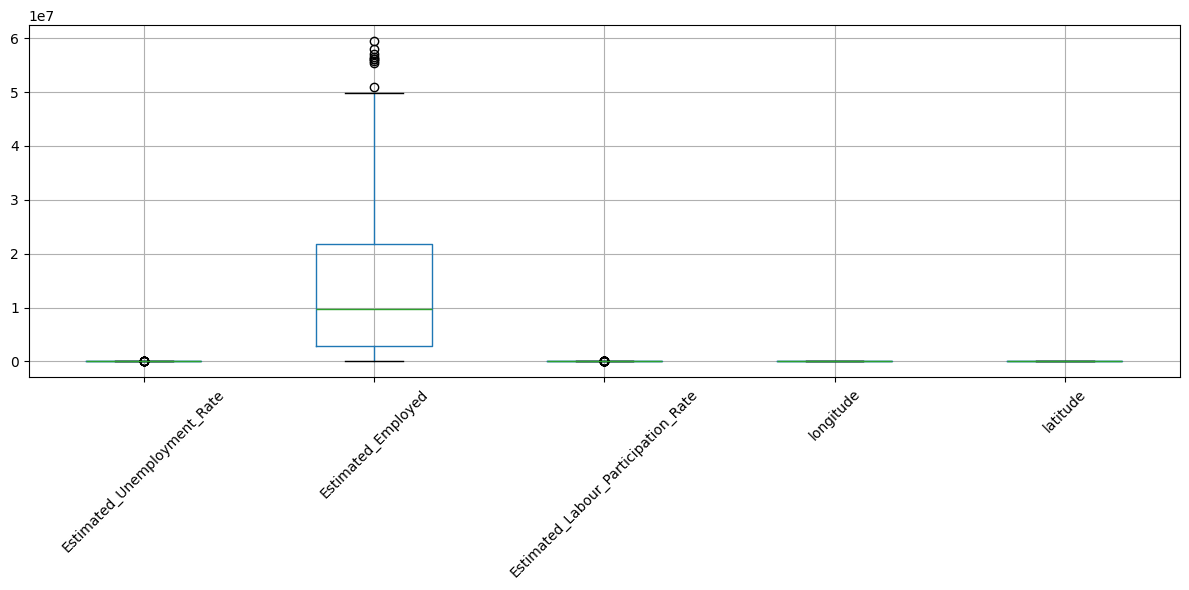

In [120]:
numeric_cols = df.select_dtypes(include='number').columns

df.boxplot(column=list(numeric_cols), figsize=(12, 6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [121]:
Q1 = df['Estimated_Employed'].quantile(0.25)
Q3 = df['Estimated_Employed'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[df['Estimated_Employed'] > Q3 + 1.5 * IQR]
print(outliers[['Region', 'Date', 'Estimated_Employed']])

            Region         Date  Estimated_Employed
237  Uttar Pradesh   31-01-2020            59433759
238  Uttar Pradesh   29-02-2020            58060531
239  Uttar Pradesh   31-03-2020            56976338
240  Uttar Pradesh   30-04-2020            50915056
242  Uttar Pradesh   30-06-2020            55380649
243  Uttar Pradesh   31-07-2020            56201654
244  Uttar Pradesh   31-08-2020            55831744
245  Uttar Pradesh   30-09-2020            56106836
246  Uttar Pradesh   31-10-2020            56539521


5- Fixing Data types

In [122]:
df.dtypes

Region                                     str
Date                                       str
Frequency                                  str
Estimated_Unemployment_Rate            float64
Estimated_Employed                       int64
Estimated_Labour_Participation_Rate    float64
Region.1                                   str
longitude                              float64
latitude                               float64
dtype: object

##### It seems we have 2 colmuns must to change it data types ( Date, Frequency )
 

In [123]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\Elfadil\AppData\Local\Temp\ipykernel_11640\2394721818.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [124]:
df['Frequency'] = df['Frequency'].astype('str')

In [125]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Region                               267 non-null    str           
 1   Date                                 267 non-null    datetime64[us]
 2   Frequency                            267 non-null    str           
 3   Estimated_Unemployment_Rate          267 non-null    float64       
 4   Estimated_Employed                   267 non-null    int64         
 5   Estimated_Labour_Participation_Rate  267 non-null    float64       
 6   Region.1                             267 non-null    str           
 7   longitude                            267 non-null    float64       
 8   latitude                             267 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(3)
memory usage: 18.9 KB


6- Checking useless columns

In [126]:
df['Frequency'].value_counts()

Frequency
M    267
Name: count, dtype: int64

In [127]:
df.value_counts()

Region          Date        Frequency  Estimated_Unemployment_Rate  Estimated_Employed  Estimated_Labour_Participation_Rate  Region.1  longitude  latitude
Andhra Pradesh  2020-01-31  M          5.48                         16635535            41.02                                South     15.9129    79.740      1
                2020-02-29  M          5.83                         16545652            40.90                                South     15.9129    79.740      1
                2020-03-31  M          5.79                         15881197            39.18                                South     15.9129    79.740      1
                2020-04-30  M          20.51                        11336911            33.10                                South     15.9129    79.740      1
                2020-05-31  M          17.43                        12988845            36.46                                South     15.9129    79.740      1
                                             

#### ['Frequency'] in all 267 rows are just 'M' (Monthly), so it adds zero analytical value.
##### So we drope

In [128]:
df.drop(columns=['Frequency'], inplace = True)

7- #### Checking inconsistent categories

In [129]:
print(df['Region'].value_counts())

Region
Andhra Pradesh      10
Assam               10
Bihar               10
Chhattisgarh        10
Delhi               10
Goa                 10
Gujarat             10
Haryana             10
Himachal Pradesh    10
Jharkhand           10
Karnataka           10
Kerala              10
Madhya Pradesh      10
Maharashtra         10
Meghalaya           10
Odisha              10
Puducherry          10
Punjab              10
Rajasthan           10
Tamil Nadu          10
Telangana           10
Tripura             10
Uttar Pradesh       10
Uttarakhand         10
West Bengal         10
Jammu & Kashmir      9
Sikkim               8
Name: count, dtype: int64


### B- Data Analysis & Data Visualization
both in same time to shorten

In [133]:
df.head(3)

,Region,Date,Estimated_Unemployment_Rate,Estimated_Employed,Estimated_Labour_Participation_Rate,Region.1,longitude,latitude
0,Andhra Pradesh,2020-01-31,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,5.79,15881197,39.18,South,15.9129,79.74


In [134]:
df.tail(3)

,Region,Date,Estimated_Unemployment_Rate,Estimated_Employed,Estimated_Labour_Participation_Rate,Region.1,longitude,latitude
264,West Bengal,2020-08-31,14.87,33298644,47.48,East,22.9868,87.855
265,West Bengal,2020-09-30,9.35,35707239,47.73,East,22.9868,87.855
266,West Bengal,2020-10-31,9.98,33962549,45.63,East,22.9868,87.855


#### A- Unemployment

1- Which region has the highest/lowest unemployment rate?

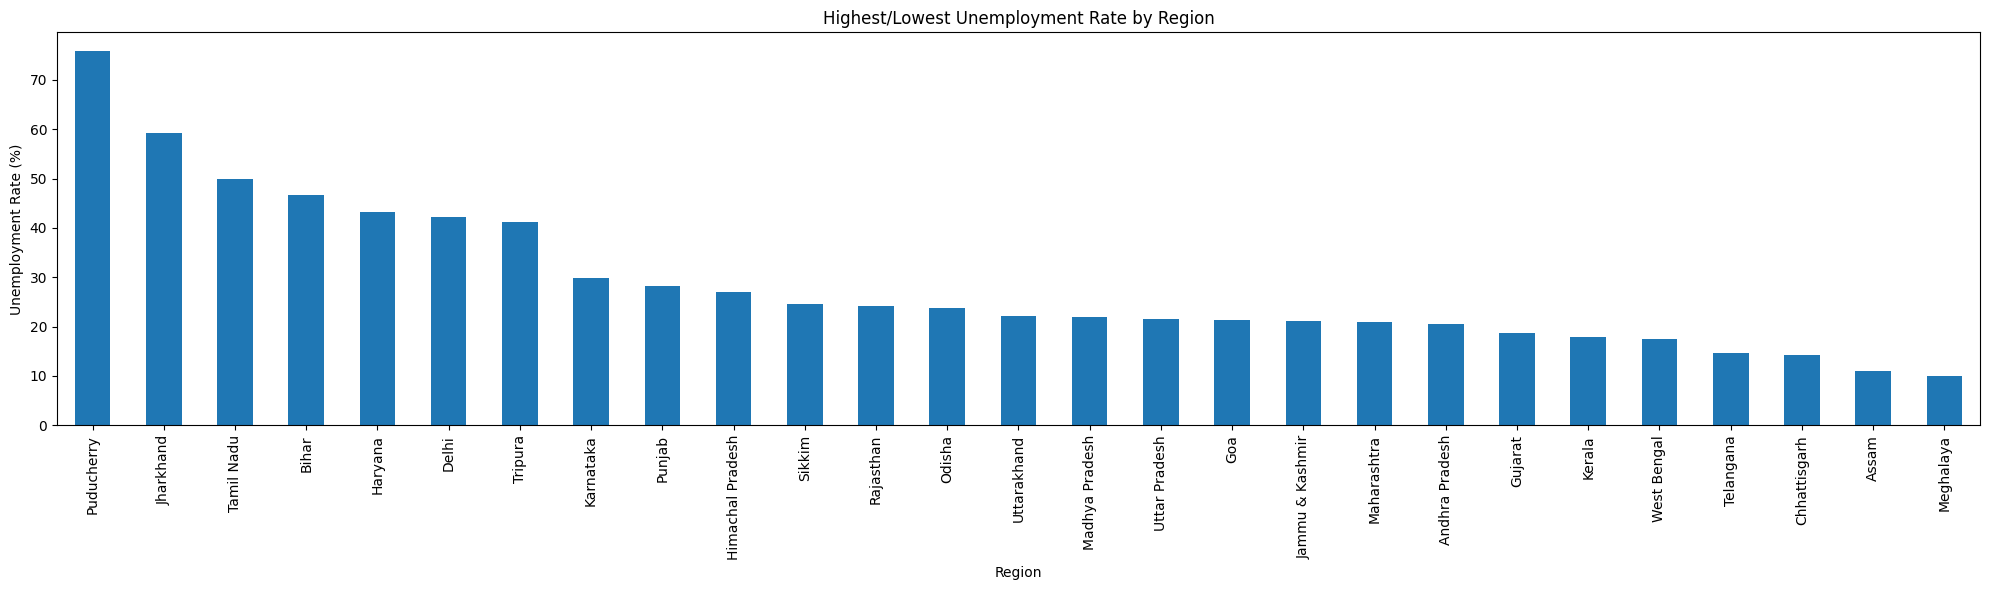

In [ ]:
df.groupby('Region')['Estimated_Unemployment_Rate'].max().sort_values(ascending=False).plot(kind='bar', figsize=(20, 6), title='Highest/Lowest Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

In [1]:
## Puducherry has the highest unemployment rate (~75%) while Meghalaya has the lowest (~9%), showing a significant gap across Indian regions.

2- How did unemployment change over time (Jan–Oct 2020)?

In [146]:
df.head(1)

,Region,Date,Estimated_Unemployment_Rate,Estimated_Employed,Estimated_Labour_Participation_Rate,Region.1,longitude,latitude
0,Andhra Pradesh,2020-01-31,5.48,16635535,41.02,South,15.9129,79.74


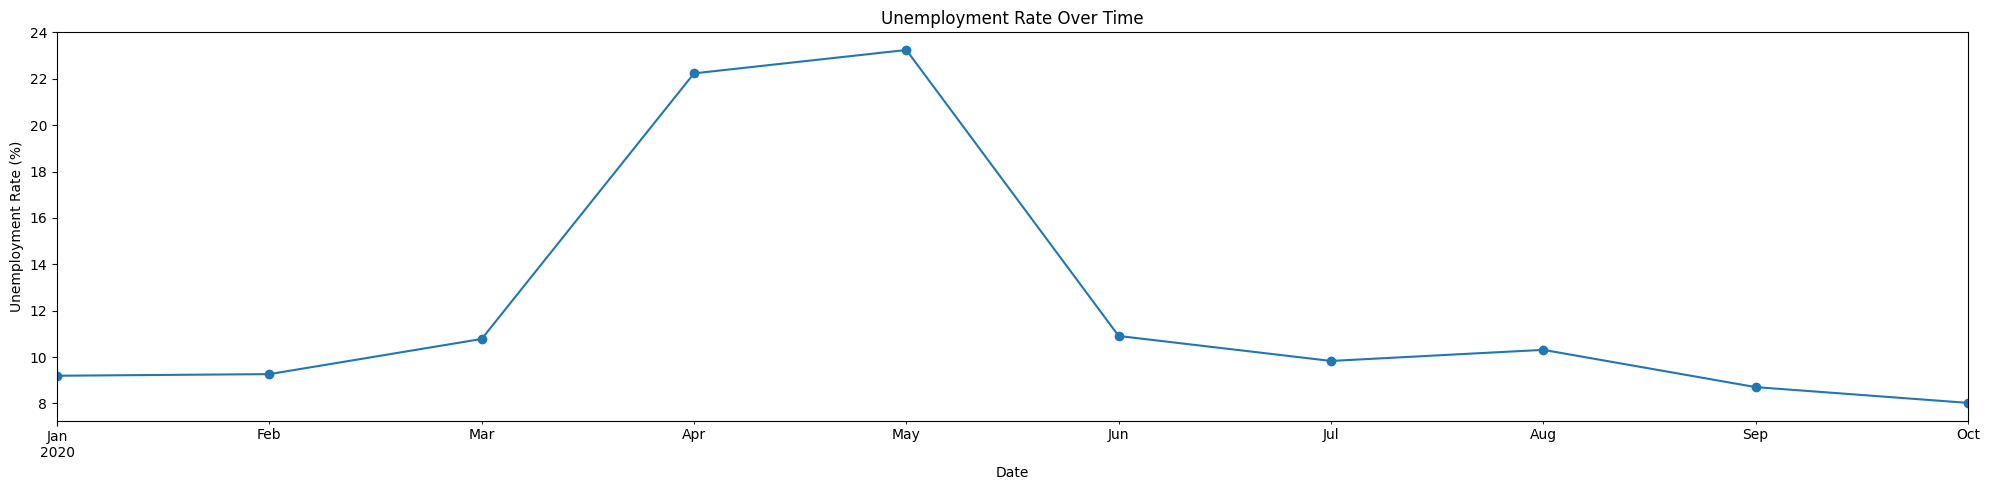

In [156]:
df.groupby('Date')['Estimated_Unemployment_Rate'].mean().plot(figsize=(20, 5), marker='o', title='Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

In [ ]:
## Unemployment spiked sharply from March to May 2020 (peaking at ~23%) due to COVID-19 lockdowns, then recovered steadily back to ~8% by October 2020.

In [147]:
df.head(1)

,Region,Date,Estimated_Unemployment_Rate,Estimated_Employed,Estimated_Labour_Participation_Rate,Region.1,longitude,latitude
0,Andhra Pradesh,2020-01-31,5.48,16635535,41.02,South,15.9129,79.74


3- Which region improved or worsened the most over time?

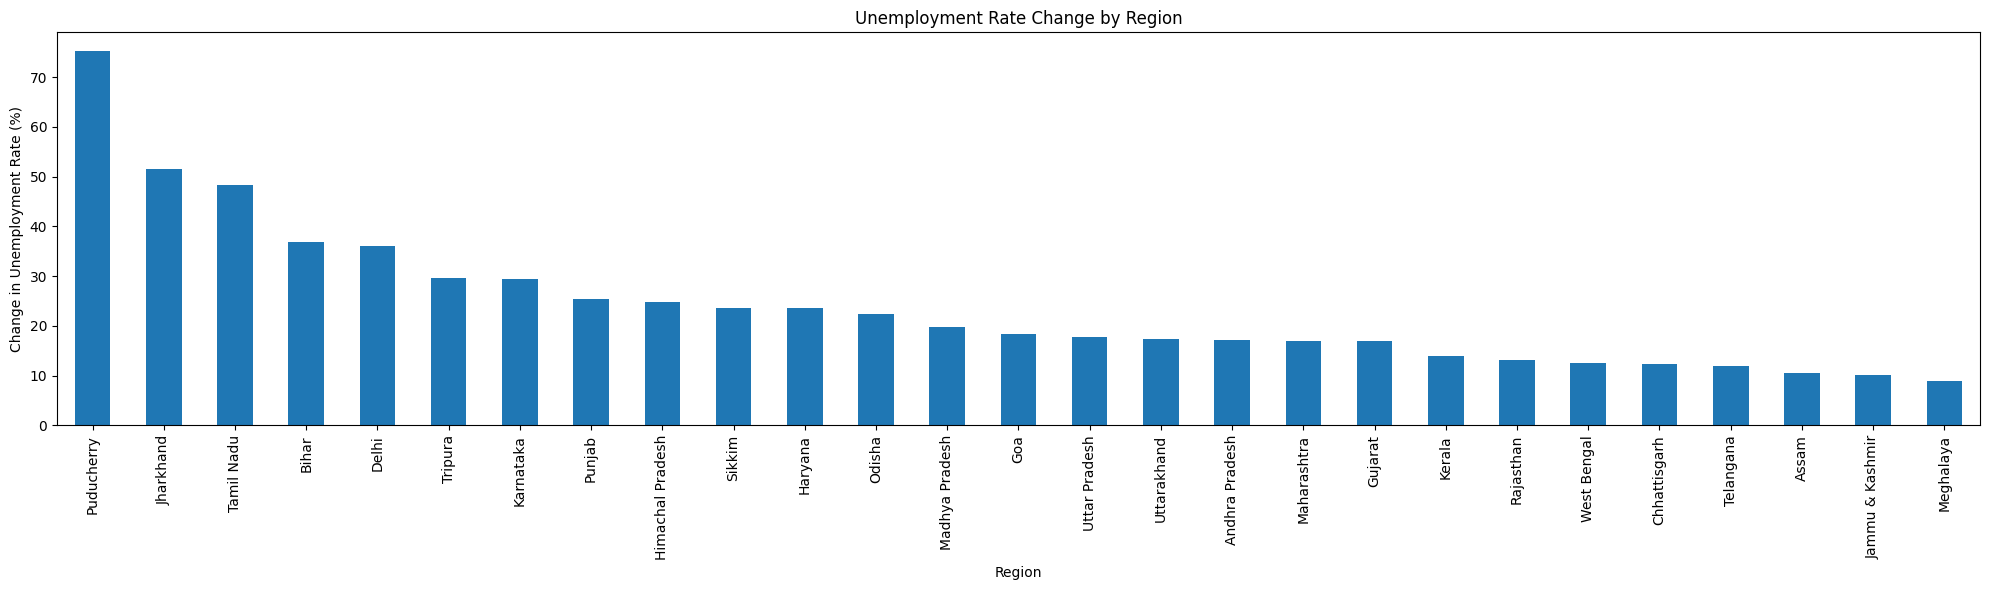

In [155]:
(df.groupby('Region')['Estimated_Unemployment_Rate'].max() - df.groupby('Region')['Estimated_Unemployment_Rate'].min()).sort_values(ascending=False).plot(kind='bar', figsize=(20, 6), title='Unemployment Rate Change by Region')
plt.xlabel('Region')
plt.ylabel('Change in Unemployment Rate (%)')
plt.tight_layout()
plt.show()

In [3]:
## Puducherry's unemployment changed the most, while Meghalaya stayed the most stable throughout 2020.

4- Does high participation mean low unemployment?


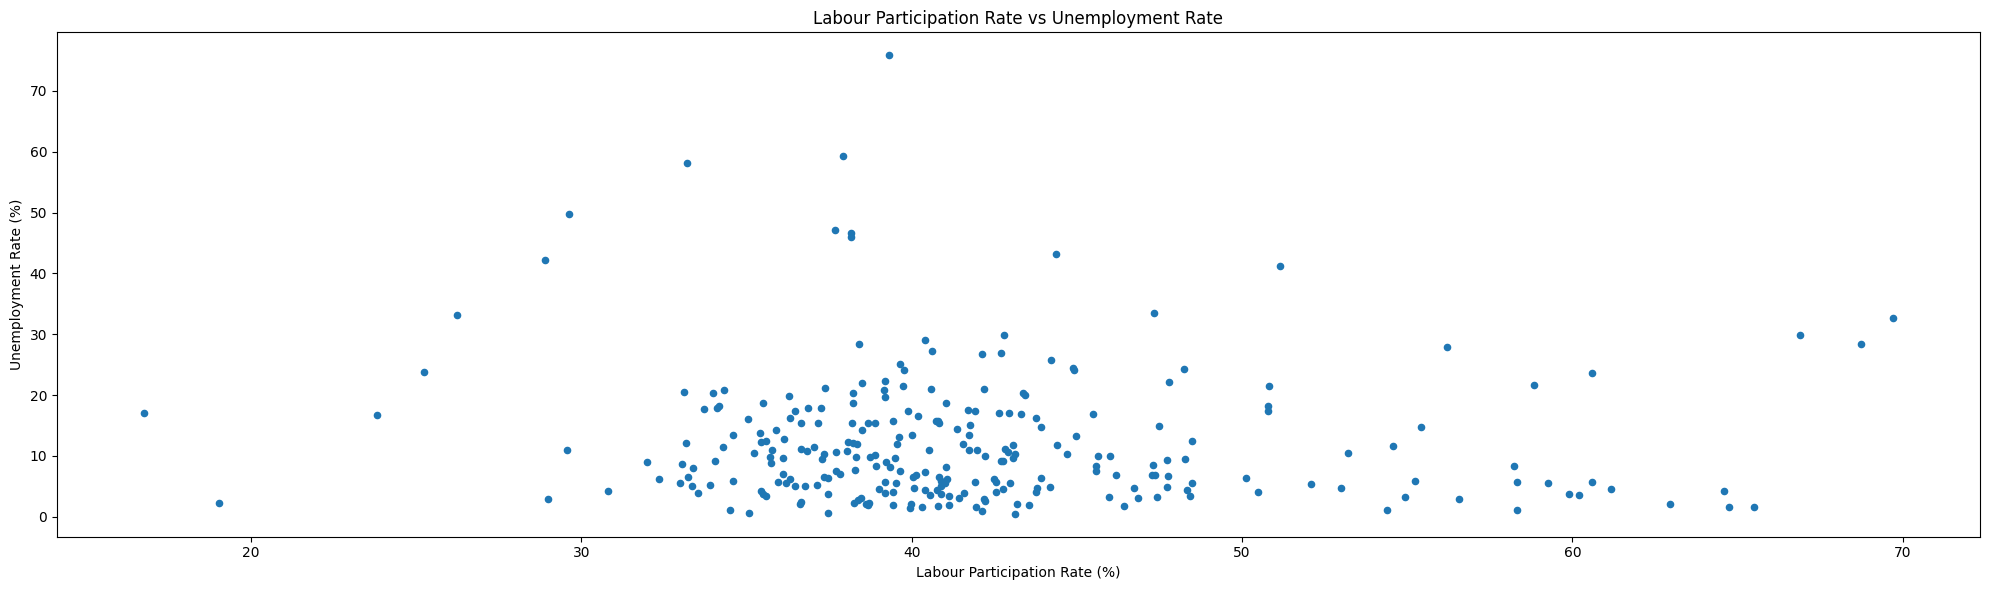

In [191]:
df.plot(kind='scatter', x='Estimated_Labour_Participation_Rate', y='Estimated_Unemployment_Rate', figsize=(20, 6), title='Labour Participation Rate vs Unemployment Rate')
plt.xlabel('Labour Participation Rate (%)')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

In [ ]:
## No clear relationship it seems. High participation does not necessarily mean low unemployment, the dots are scattered with no obvious trend.

#### B- Employment

5- Which region has the most/least employed people?

In [151]:
df.head(2)

,Region,Date,Estimated_Unemployment_Rate,Estimated_Employed,Estimated_Labour_Participation_Rate,Region.1,longitude,latitude
0,Andhra Pradesh,2020-01-31,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,5.83,16545652,40.90,South,15.9129,79.74


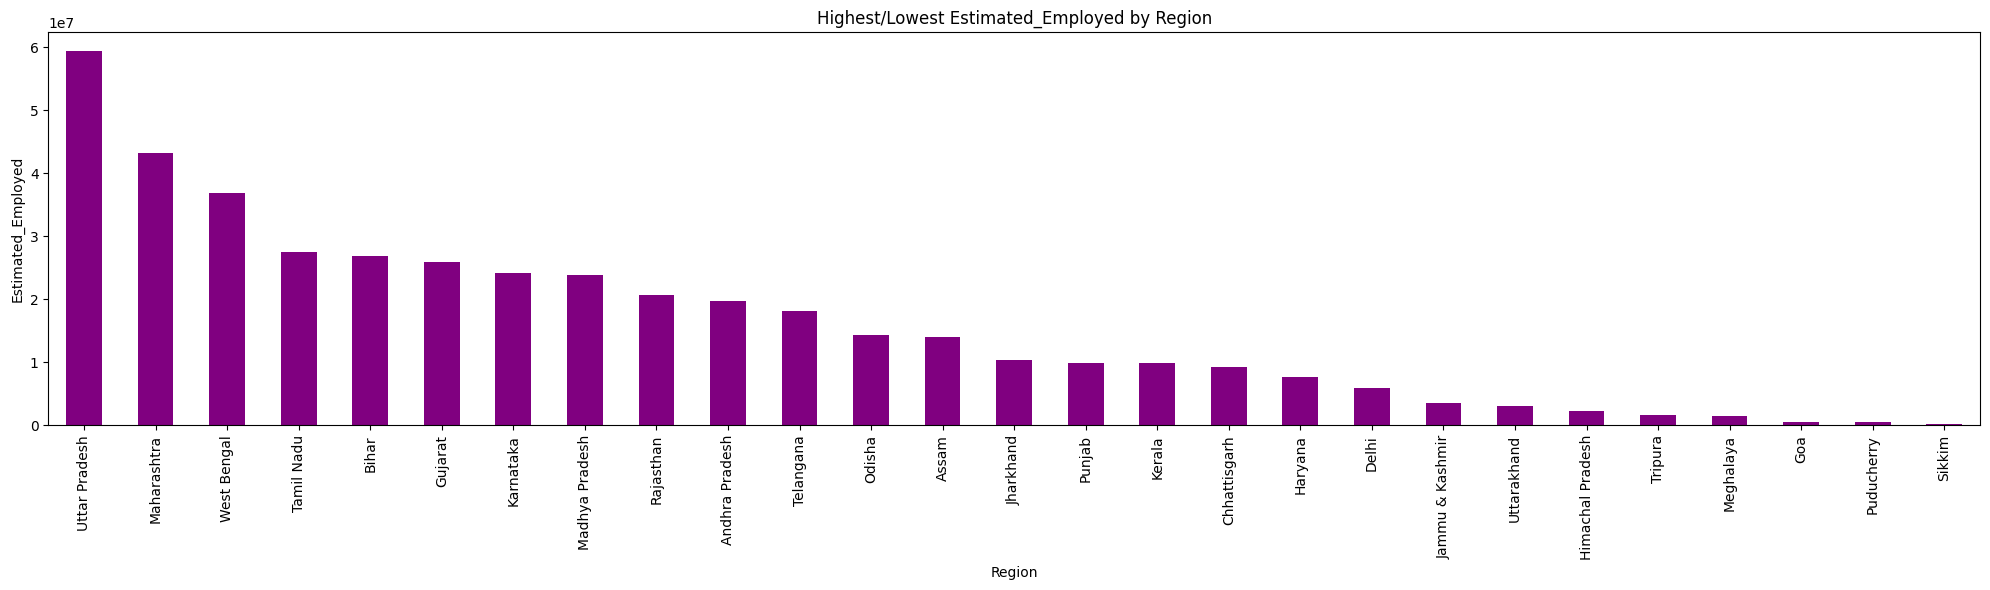

In [166]:
df.groupby('Region')['Estimated_Employed'].max().sort_values(ascending=False).plot(kind='bar', color='purple', figsize=(20, 6), title='Highest/Lowest Estimated_Employed by Region')
plt.xlabel('Region')
plt.ylabel('Estimated_Employed')
plt.tight_layout()
plt.show()

In [5]:
## Uttar Pradesh has by far the most employed people (~60M), while Sikkim and Puducherry have the least — which directly reflects their population sizes.

6- Is there a relationship between employed numbers and unemployment rate?

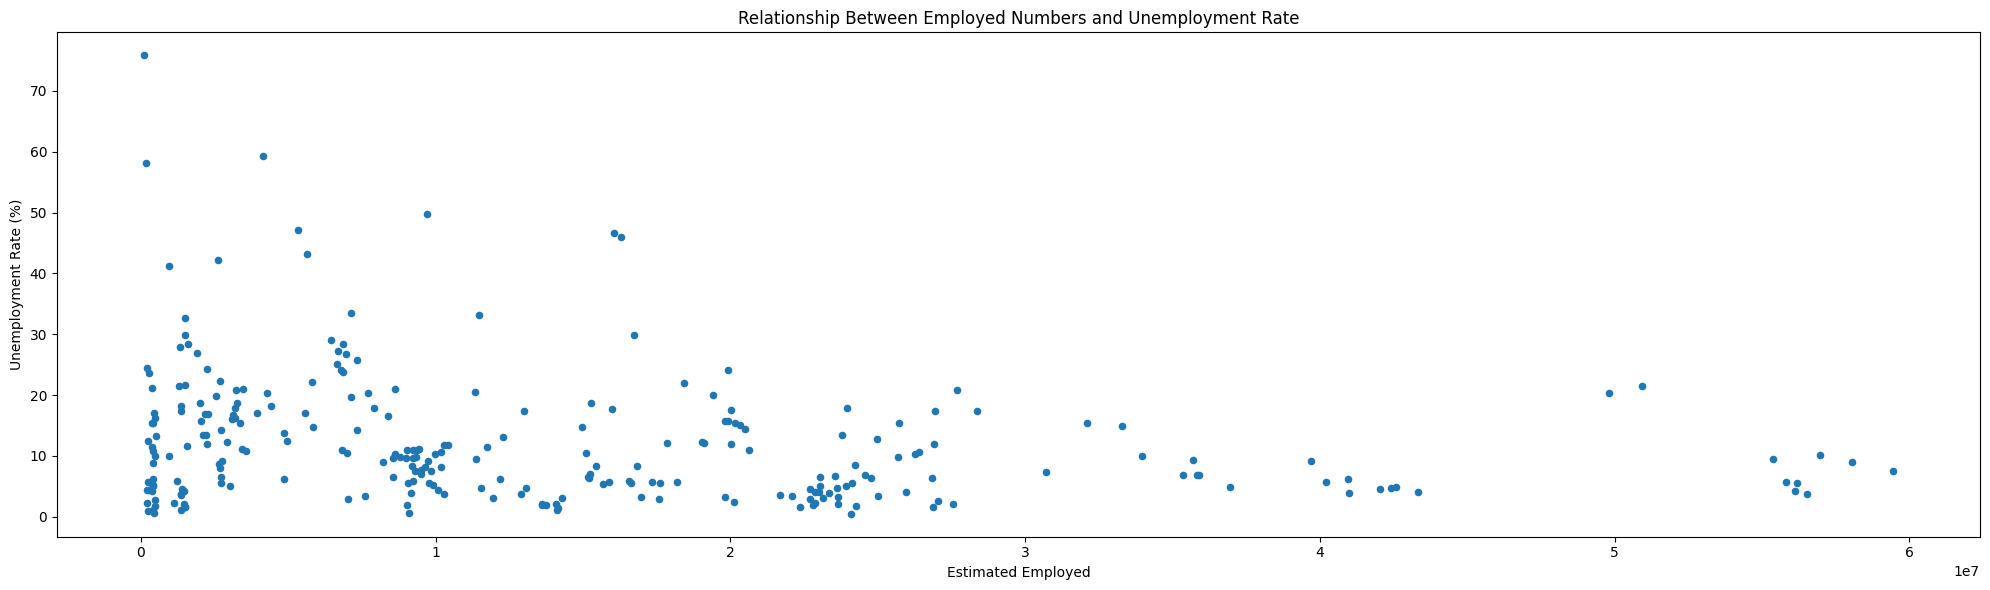

In [172]:
df.plot(kind='scatter', x='Estimated_Employed', y='Estimated_Unemployment_Rate', figsize=(20, 6), title='Relationship Between Employed Numbers and Unemployment Rate')
plt.xlabel('Estimated Employed')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

In [6]:
## No clear relationship, or a very weak negative one at best. High employment doesn't guarantee low unemployment.
## This suggests that employment rate alone don’t determine the unemployment rate

#### C- Labour Participation

7- Which region has the highest labour participation rate?

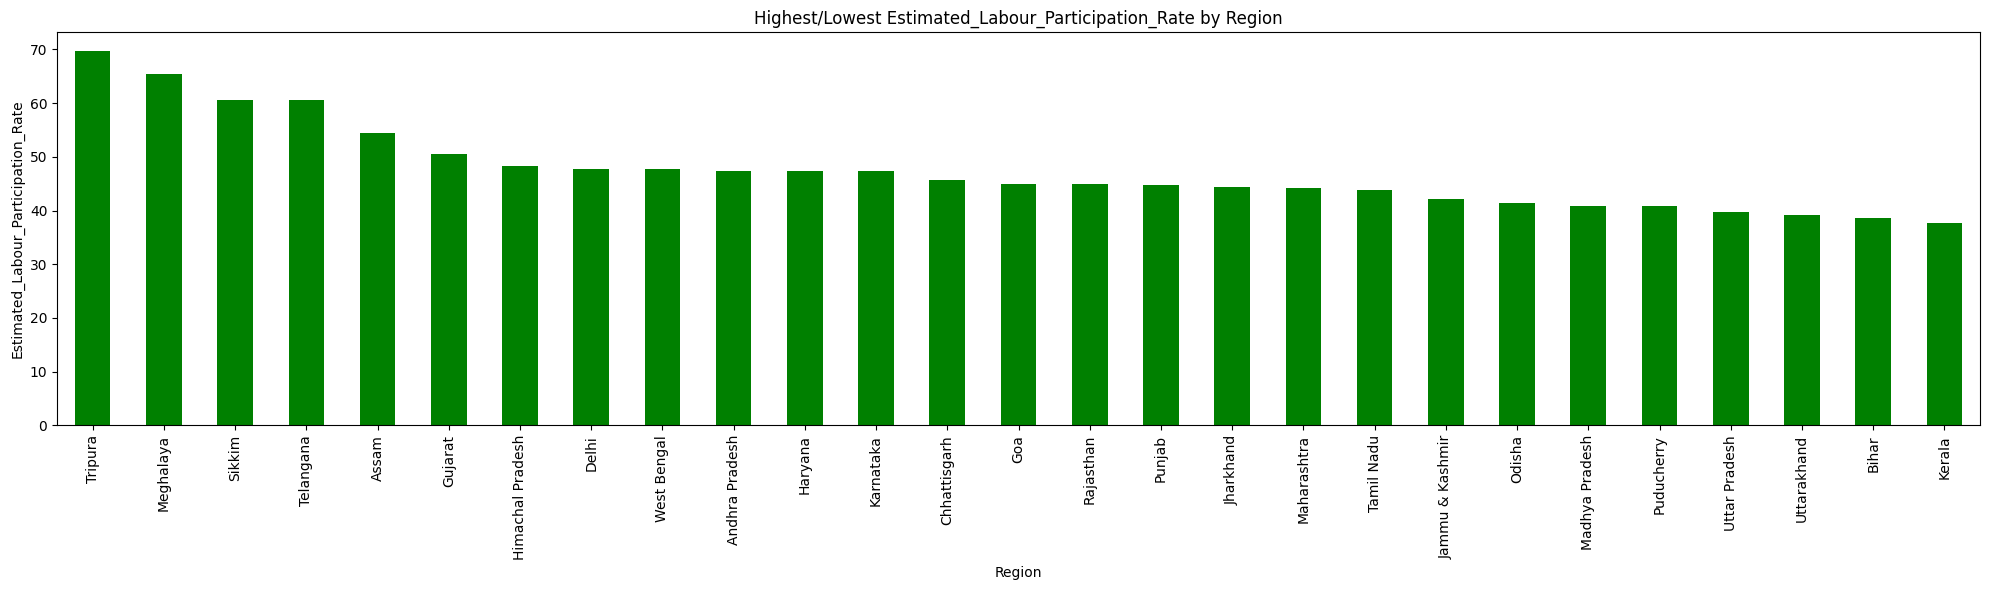

In [170]:
df.groupby('Region')['Estimated_Labour_Participation_Rate'].max().sort_values(ascending=False).plot(kind='bar', color='g' ,figsize=(20, 6), title='Highest/Lowest Estimated_Labour_Participation_Rate by Region')
plt.xlabel('Region')
plt.ylabel('Estimated_Labour_Participation_Rate')
plt.tight_layout()
plt.show()

In [7]:
## Tripura has the highest labour participation rate (~70%) while Kerala has the lowest (~37%), with most regions clustering between 40-50%.

#### D- Regional


8- Which region code (South, East, etc.) performs best overall?

In [ ]:
df.head(2)

,Region,Date,Estimated_Unemployment_Rate,Estimated_Employed,Estimated_Labour_Participation_Rate,Region.1,longitude,latitude
0,Andhra Pradesh,2020-01-31,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,5.83,16545652,40.90,South,15.9129,79.74


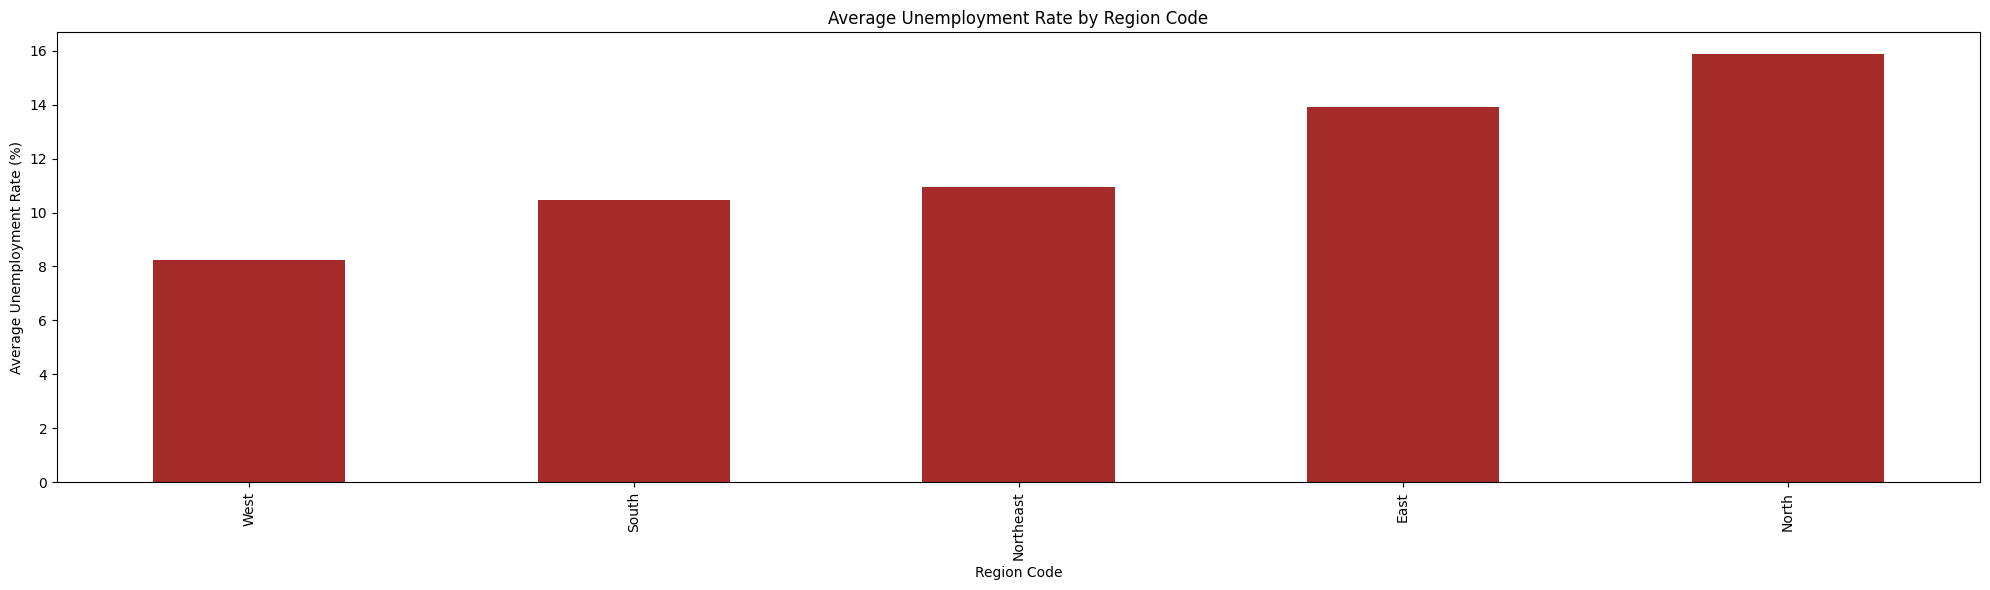

In [179]:
df.groupby('Region.1')['Estimated_Unemployment_Rate'].mean().sort_values().plot(kind='bar', color= 'brown',figsize=(20, 6), title='Average Unemployment Rate by Region Code')
plt.xlabel('Region Code')
plt.ylabel('Average Unemployment Rate (%)')
plt.tight_layout()
plt.show()

In [8]:
## West performs best with the lowest average unemployment (~8%), while North performs worst with the highest (~16%).

9- Are there patterns between geographic location (lat/long) and unemployment?


In [186]:
df.head(2)

,Region,Date,Estimated_Unemployment_Rate,Estimated_Employed,Estimated_Labour_Participation_Rate,Region.1,longitude,latitude
0,Andhra Pradesh,2020-01-31,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,5.83,16545652,40.90,South,15.9129,79.74


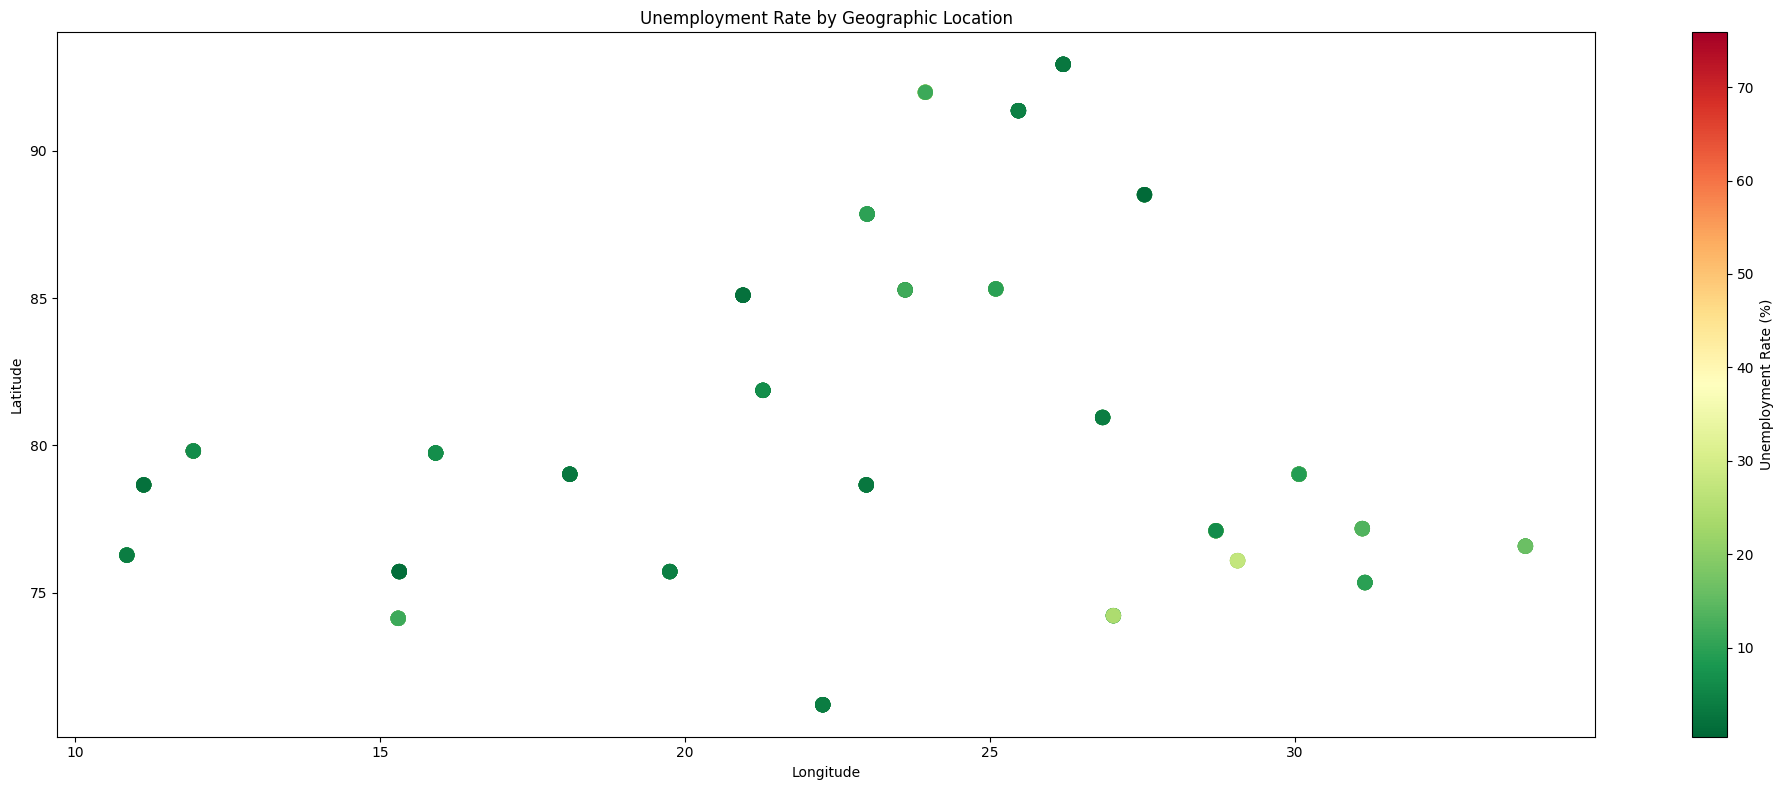

In [185]:
plt.figure(figsize=(20, 8))
scatter = plt.scatter(df['longitude'], df['latitude'], 
                      c=df['Estimated_Unemployment_Rate'], 
                      cmap='RdYlGn_r', s=100)
plt.colorbar(scatter, label='Unemployment Rate (%)')
plt.title('Unemployment Rate by Geographic Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

In [9]:
## Most regions are green (low unemployment), with no strong geographic pattern  

10- Did COVID-19 impact unemployment in mid-2020?

In [187]:
df.head(2)

,Region,Date,Estimated_Unemployment_Rate,Estimated_Employed,Estimated_Labour_Participation_Rate,Region.1,longitude,latitude
0,Andhra Pradesh,2020-01-31,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,5.83,16545652,40.90,South,15.9129,79.74


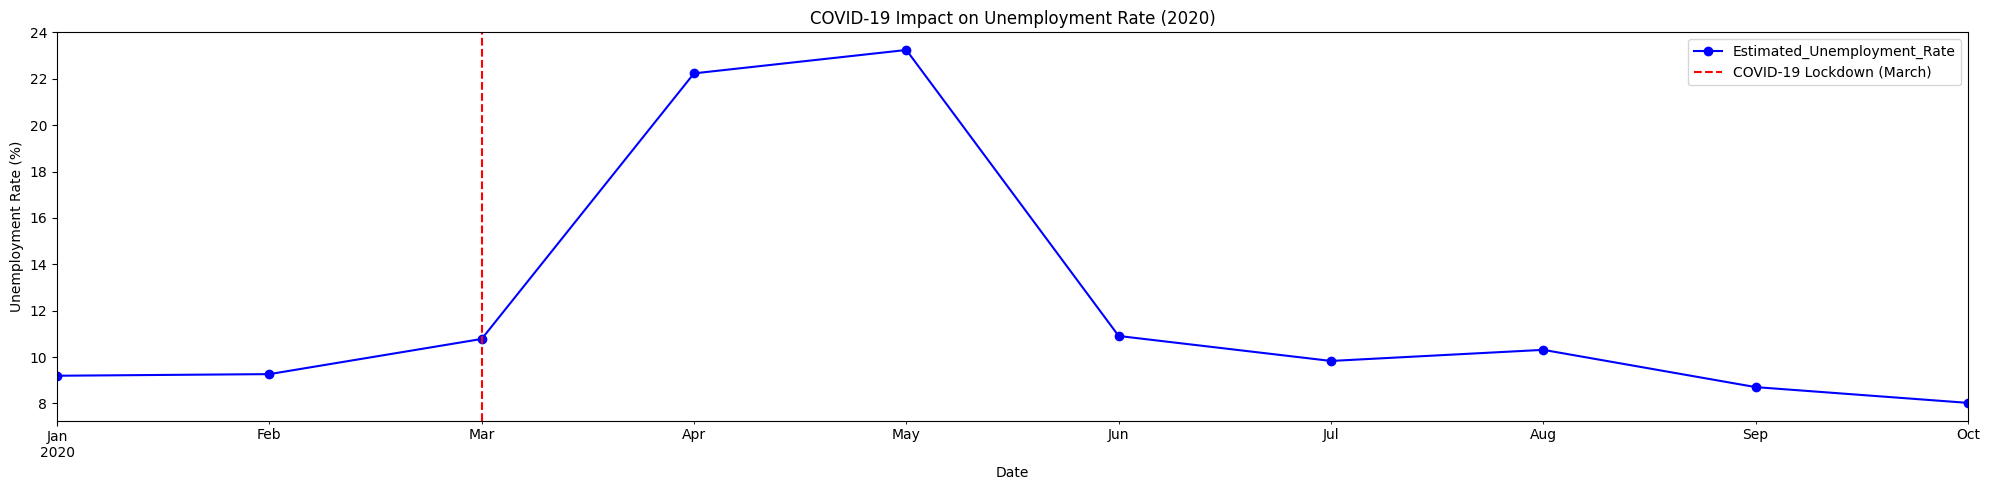

In [189]:
df.groupby('Date')['Estimated_Unemployment_Rate'].mean().plot(figsize=(20, 5), marker='o', color='blue', title='COVID-19 Impact on Unemployment Rate (2020)')
plt.axvline(x=pd.Timestamp('2020-03-01'), color='red', linestyle='--', label='COVID-19 Lockdown (March)')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
## Yes unemployment spiked sharply right after the March lockdown, nearly tripling from ~9% to ~23% by May, then gradually recovered to pre-COVID levels by October 2020.

### The insights Gained

India's unemployment data reveals clear regional and temporal disparities that demand targeted policy action. The North region and states like Puducherry and Jharkhand require urgent job creation interventions, while the West region's success (~8% average) should serve as a replicable model. The COVID-19 period exposed a critical vulnerability unemployment nearly tripled in two months highlighting the need for a rapid economic response framework for future crises. Finally, since high labour participation didn't translate to lower unemployment, policies must prioritize job creation over workforce mobilization alone.

# Done